<a href="https://colab.research.google.com/github/lallen-student/hw-test/blob/main/DACSS_603_Tutorial1_Descriptive_Statistics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# How to complete the tutorial

- Read through the text and run code chunks!
- Some code chunks are already filled in for you.
- Others don't have code in them, just write your own code based on instructions.
- If you would like to add text or code blocks, or take notes on your own copy, **make sure you save a copy to your Drive**.
- Some of the things you find here might be on the weekly quiz.

# Load Data

We will use the 'penguins' dataset from the **[palmerpenguins](https://allisonhorst.github.io/palmerpenguins/)** dataset for this tutorial.

In [ ]:
install.packages('palmerpenguins')
library(palmerpenguins)
data('penguins', package = 'palmerpenguins')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘palmerpenguins’


The following objects are masked from ‘package:datasets’:

    penguins, penguins_raw




It's a good idea to just use the `head()` function to print some of the dataset. Because the dataset directly comes in a tibble format, below every column name is a tag such as <fct> (factor) or <dbl> (double) that indicates what type (class) that variable is.

In [ ]:
head(penguins, n = 10)

species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<fct>,<int>
Adelie,Torgersen,39.1,18.7,181,3750,male,2007
Adelie,Torgersen,39.5,17.4,186,3800,female,2007
Adelie,Torgersen,40.3,18.0,195,3250,female,2007
Adelie,Torgersen,NA,NA,NA,NA,NA,2007
Adelie,Torgersen,36.7,19.3,193,3450,female,2007
Adelie,Torgersen,39.3,20.6,190,3650,male,2007
Adelie,Torgersen,38.9,17.8,181,3625,female,2007
Adelie,Torgersen,39.2,19.6,195,4675,male,2007
Adelie,Torgersen,34.1,18.1,193,3475,NA,2007


The `penguins` dataset has one observation in every row---a feature of tidy datasets. In the code chunk below, use the `nrow()` function to check out how many observations (i.e. rows) the dataset has.

In [ ]:
# Write code here
nrow(penguins)

[1] 344

# Check missing values

When we used the `head()` function, we saw that there were some missing values (NA). The `is.na()` function can be used to identify missing values. However, it's output is not super useful for large datasets. For example, let's see the missing values in the `bill_length_mm` variable:

In [ ]:
is.na(penguins$bill_length_mm)

[1] FALSE FALSE FALSE  TRUE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
 [13] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
 [25] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
 [37] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
 [49] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
 [61] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
 [73] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
 [85] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
 [97] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[109] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[121] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[133] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[145] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[157] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[169] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[181] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[193] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[205] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[217] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[229] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[241] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[253] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[265] FALSE FALSE FALSE FALSE FALSE FALSE FALSE  TRUE FALSE FALSE FALSE FALSE
[277] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[289] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[301] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[313] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[325] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[337] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE

This is not very useful. A more useful information can be the indices of the observations for which `bill_length_mm` is missing. We can use the `which()` function for that:

In [ ]:
which(is.na(penguins$bill_depth_mm))

[1]   4 272

You can use the `complete.cases()` function to find all observations for which no variable is missing. You can use `na.omit()` to return a dataframe where any observation with any missing variable is eliminated. The exploration of those functions are left to you.

In general, when you encounter missing values, it's best to explore why they are missing, whether there is a large number of missing values, and if it appears to be systematic. (e.g. all values from a time period or place is missing or it is missing for a particular demographic etc.)

# Summarizing Information

Use the `summary()` function on the `penguins` tibble. Do any of the other variables have missing values?

In [ ]:
summary(penguins)

      species          island    bill_length_mm  bill_depth_mm  
 Adelie   :152   Biscoe   :168   Min.   :32.10   Min.   :13.10  
 Chinstrap: 68   Dream    :124   1st Qu.:39.23   1st Qu.:15.60  
 Gentoo   :124   Torgersen: 52   Median :44.45   Median :17.30  
                                 Mean   :43.92   Mean   :17.15  
                                 3rd Qu.:48.50   3rd Qu.:18.70  
                                 Max.   :59.60   Max.   :21.50  
                                 NA's   :2       NA's   :2      
 flipper_length_mm  body_mass_g       sex           year     
 Min.   :172.0     Min.   :2700   female:165   Min.   :2007  
 1st Qu.:190.0     1st Qu.:3550   male  :168   1st Qu.:2007  
 Median :197.0     Median :4050   NA's  : 11   Median :2008  
 Mean   :200.9     Mean   :4202                Mean   :2008  
 3rd Qu.:213.0     3rd Qu.:4750                3rd Qu.:2009  
 Max.   :231.0     Max.   :6300                Max.   :2009  
 NA's   :2         NA's   :2                  

The `glimpse()` function from the dplyr package provides another way of summarizing the information in a dataframe.

In [ ]:
library(dplyr)
glimpse(penguins)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




Rows: 344
Columns: 8
$ species           <fct> Adelie, Adelie, Adelie, Adelie, Adelie, Adelie, Adel…
$ island            <fct> Torgersen, Torgersen, Torgersen, Torgersen, Torgerse…
$ bill_length_mm    <dbl> 39.1, 39.5, 40.3, NA, 36.7, 39.3, 38.9, 39.2, 34.1, …
$ bill_depth_mm     <dbl> 18.7, 17.4, 18.0, NA, 19.3, 20.6, 17.8, 19.6, 18.1, …
$ flipper_length_mm <int> 181, 186, 195, NA, 193, 190, 181, 195, 193, 190, 186…
$ body_mass_g       <int> 3750, 3800, 3250, NA, 3450, 3650, 3625, 4675, 3475, …
$ sex               <fct> male, female, female, NA, female, male, female, male…
$ year              <int> 2007, 2007, 2007, 2007, 2007, 2007, 2007, 2007, 2007…


# Mean, Median, Variance, and Standard Deviation

We use the `mean()` function to calculate the mean of a variable. Let's use it to calculate the mean of the `bill_length_mm` variable. Because the variable has missing values, we need to set the `na.rm` argument to `TRUE` (or just `T`) so that it ignores the missing values when doing the calculation. We'll need to do that for some other functions too.

In [ ]:
mean(penguins$bill_length_mm, na.rm = T)

[1] 43.92193

The median is another measure of central tendency. Use the `median()` function to calculate the median.

In [ ]:
# Write code here
median(penguins$bill_length_mm, na.rm = T)

[1] 44.45

The `var()` function calculates the (sample) variance. Let's use it to calculate the variance of the `bill_length_mm` variable.

In [ ]:
var(penguins$bill_length_mm, na.rm = T)


[1] 29.80705

The `sd()` function calculates the (sample) standard deviation. Standard deviation is the square root of variance. Let's take the sd() of the `bill_length_mm` variable

In [ ]:
sd(penguins$bill_length_mm, na.rm = T)

[1] 5.459584

Let's see if it actually equals the square root of the variance.

In [ ]:
sqrt(var(penguins$bill_length_mm, na.rm = T)) == sd(penguins$bill_length_mm, na.rm = T)

[1] TRUE

Do you expect the variance, standard deviation and mean of the `flipper_length_mm` variable to be higher or lower than `bill_length_mm` based on your knowledge of the penguin anotomy?

Calculate the variance, standard deviation and mean of the `flipper_length_mm` variable and see if it's what you expect.

In [ ]:
# Write code here
var(penguins$flipper_length_mm, na.rm = T)

[1] 197.7318

# Minimum, Maximum, Range, and Interquartile Range

The `max()` and `min()` functions can be used to calculate the maximum and minimum of a variable.

In [ ]:
max(penguins$bill_length_mm, na.rm = T)
min(penguins$bill_length_mm, na.rm = T)


[1] 59.6

[1] 32.1

The `range` of the variable is the difference between its maximum and minimum value---but the `range()` function in R will give the maximum and minimum value, allowing one to calculate the difference or to just state the plausible set of values the variable could take.

In [ ]:
range(penguins$bill_length_mm, na.rm = T)

[1] 32.1 59.6

We could use the `diff()` function if we were interested in the difference.

In [ ]:
diff(range(penguins$bill_length_mm, na.rm = T))

[1] 27.5

The interquartile range---the difference between the third (upper) and first (lower) quartile---is calculated with the `IQR()` function.

In [ ]:
IQR(penguins$bill_length_mm, na.rm = T)

[1] 9.275

**Your turn:** Calculate the range and interquartile range of the `flipper_length_mm` variable.

In [ ]:
# Write code here:
range(penguins$flipper_length_mm, na.rm=T)
IQR(penguins$flipper_length_mm, na.rm=T)

[1] 172 231

[1] 23

# Histograms: Visualize the distribution of a data

We can draw a histogram to get a better sense of how the data is distributed.

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_bin()`).”


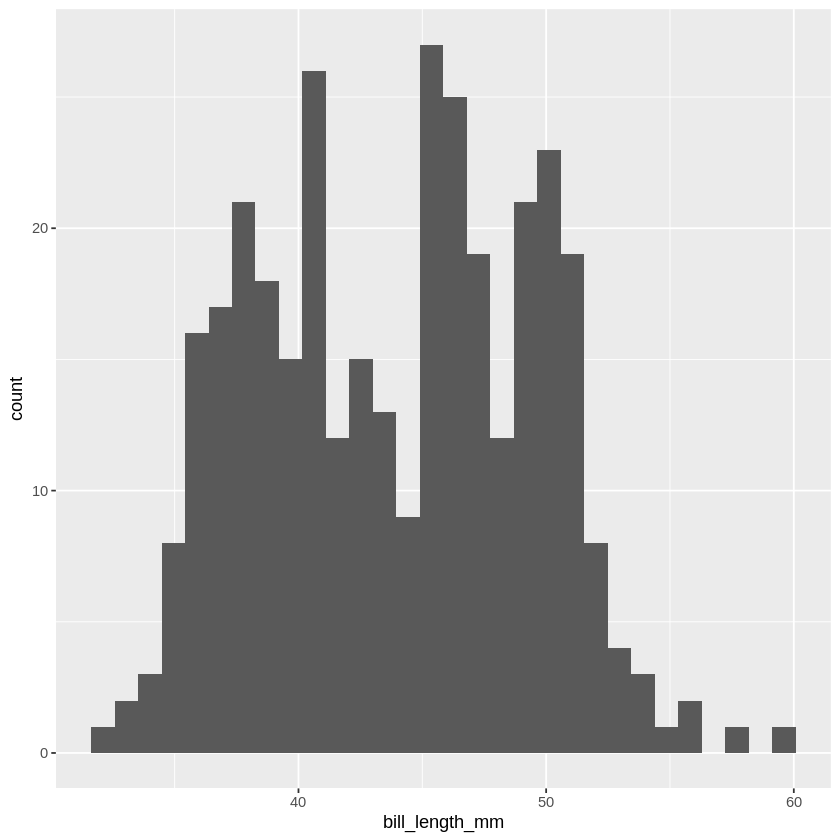

In [ ]:
library(ggplot2)

ggplot(penguins, aes(x = bill_length_mm)) +
  geom_histogram()

Now draw the histogram of `flipper_length_mm`.

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_bin()`).”


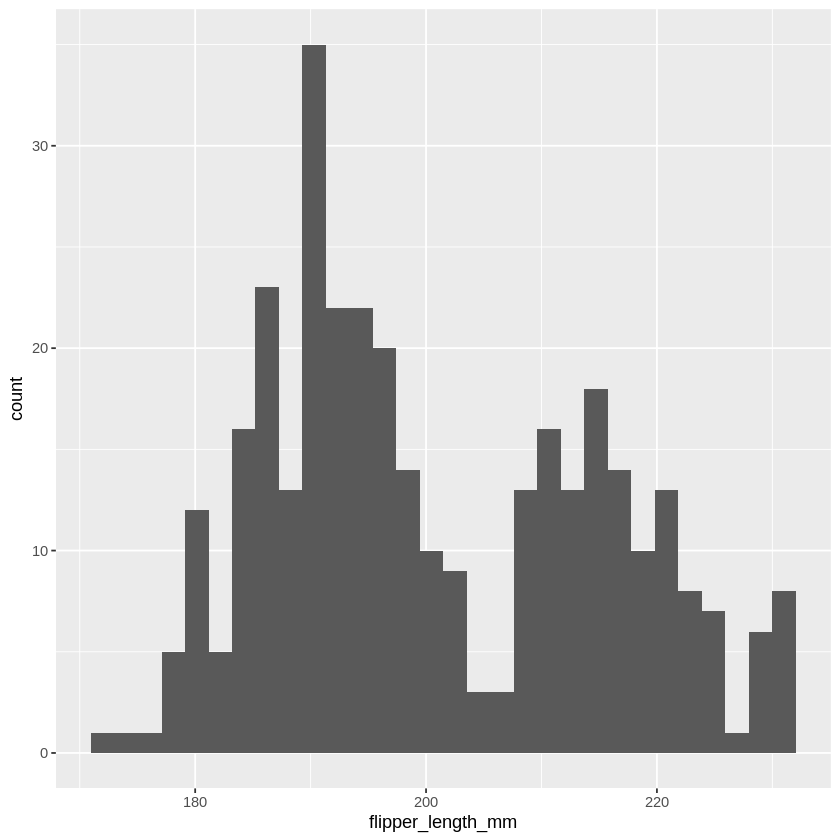

In [ ]:
# Write code here:
ggplot(penguins, aes(x = flipper_length_mm)) +
  geom_histogram()

Notice that both histograms look like they have more than one center (bi-modal or tri-modal as opposed to unimodal). This can be because there are systematic differences within the subgroups of observations. Plot the `flipper_length_mm` as separate histograms for each species and sex.

(**Hint:** Add `+ facet_grid(species ~ sex)` to the previous histogram. If you don't want NA's to be plotted, wrap `penguins` with `na.omit()` i.e. use `na.omit(penguins)` as your data.)

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


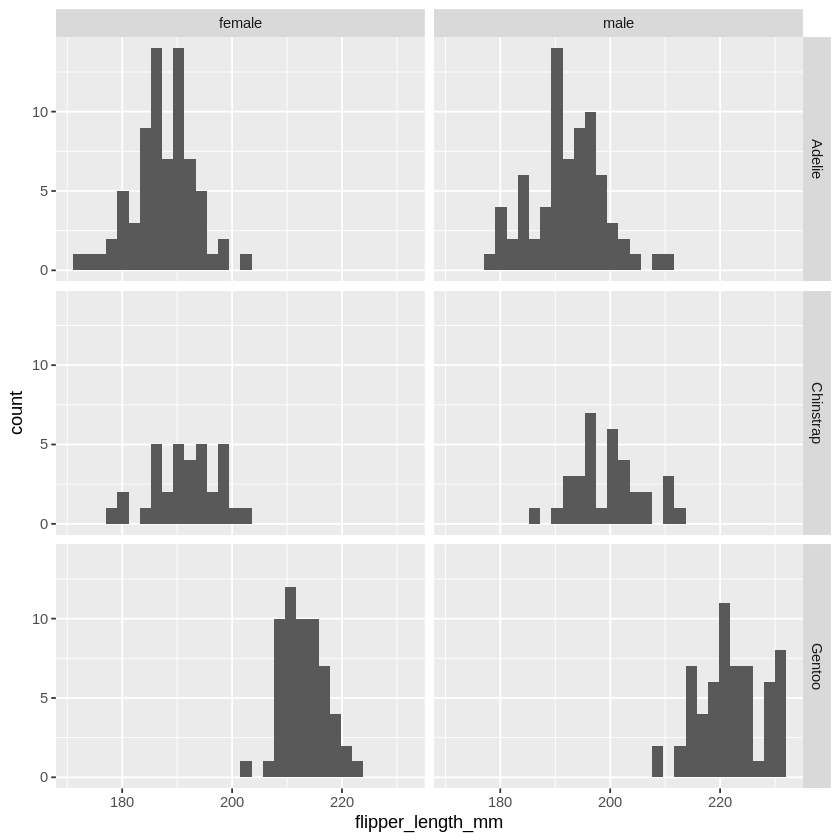

In [ ]:
# Write code here
ggplot(na.omit(penguins), aes(x = flipper_length_mm)) +
  geom_histogram()+
  facet_grid(species ~ sex)


Just by looking at the graph, do you think each species has a different mean `flipper_length_mm` value? In other words, would your best guess of a flipper length for a penguin change if you knew which species it belonged to? How about `sex`?

We can calculate the mean value for each subgroup. Let's calculate the mean flipper length for female Adelie penguins:

In [ ]:
penguins %>%
  filter(species == 'Adelie' & sex == 'female') %>%
  pull(flipper_length_mm) %>%
  mean()



[1] 187.7945

**Your turn:** Looking at the histogram, do you expect the value to be higher or lower? Calculate the mean flipper_length of the male Gentoo penguins.


In [ ]:
# Write code here
penguins %>%
  filter(species == 'Gentoo' & sex == 'male') %>%
  pull(flipper_length_mm) %>%
  mean()

[1] 221.541

Variance (and thus standard deviation) is a measure of uncertainty. A high variance indicates high uncertainty. If knowing the species and sex makes our guesses about mean values better, then it should also reduce the variance, i.e. uncertainty, around our guess.

Let's calculate the variance of `flipper_length_mm` for female Adelie penguins.

In [ ]:
penguins %>%
  filter(species == 'Adelie' & sex == 'female') %>%
  pull(flipper_length_mm) %>%
  var()

[1] 31.30441

Is this variance really lower than what you previously found for the whole `flipper_length_mm` variable?